# Imports and Setup


In [ ]:
# Standard libraries for numerical operations and plotting
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Set a consistent style for plots
plt.style.use('seaborn-v0_8-whitegrid')

# Bernoulli Outcome Simulation Setup

These functions simulate the generating Bernoulli Random Variables and estimating their mean.

In [ ]:
# Next: Replace with actual qiskit circuits
def simulate_swap_test(p_true, n_samples):
    """
    Simulates the outcome of a SWAP test.

    The SWAP test measures the overlap, which translates to a probability
    of measuring |0> on the ancilla qubit. We model this as a Bernoulli trial.

    Args:
        p_true (float): The true probability of success (e.g., ancilla measuring |0>).
        n_samples (int): The number of shots (samples) to take.

    Returns:
        np.array: An array of 0s and 1s representing the measurement outcomes.
    """
    return np.random.binomial(1, p_true, n_samples) # concentration inequality

def estimate_probability(samples):
    """
    Estimates the probability of success from a set of samples.

    Args:
        samples (np.array): An array of 0s and 1s.

    Returns:
        float: The estimated probability (the sample mean).
    """
    return np.mean(samples)

# Concentration Inequality Implementations
These functions calculate the confidence intervals for each of the four methods.


In [ ]:
def hoeffding_bound(p_est, n, delta):
    """
    Calculates the Hoeffding confidence interval.
    Provides a tight bound for independent, bounded variables in [0, 1].
    """
    radius = np.sqrt(np.log(2/delta) / (2 * n))
    return max(0, p_est - radius), min(1, p_est + radius)

def chernoff_bound(p_est, n, delta):
    """
    Calculates the Chernoff confidence interval.
    Specifically designed for sums of independent Bernoulli random variables.
    """
    epsilon = np.sqrt(3 * np.log(2/delta) / n)
    radius = epsilon
    return max(0, p_est - radius), min(1, p_est + radius)

def chebyshev_bound(p_est, n, delta):
    """
    Calculates the Chebyshev confidence interval using the EMPIRICAL variance.

    NOTE: This is a practical choice and does not provide a strict theoretical
    guarantee because the variance is estimated from the data. A guaranteed
    bound would use the worst-case variance (0.25 for Bernoulli), which is much looser.
    """
    var_est = p_est * (1 - p_est)
    if var_est == 0:
        return p_est, p_est # No variance, interval is a point
    radius = np.sqrt(var_est / (delta * n))
    return max(0, p_est - radius), min(1, p_est + radius)

def markov_bound(p_est, delta):
    """
    Calculates a representative Markov "interval".

    NOTE: Markov's inequality is extremely general and not practical for
    constructing tight confidence intervals for bounded variables. This function
    provides a very loose interval to illustrate its impracticality.
    """
    # This radius is not a standard derivation but serves to show its looseness.
    radius = 1.0 / delta
    return max(0, p_est - radius), min(1, p_est + radius)

# Sample Size Calculation for Target Accuracy

These functions calculate the minimum number of samples (`n`) required to achieve a desired accuracy (`epsilon`) with a given confidence level (`1 - delta`).

In [ ]:
def sample_size_hoeffding(epsilon, delta):
    """Sample size needed for Hoeffding to achieve epsilon accuracy."""
    return int(np.ceil(np.log(2/delta) / (2 * epsilon**2)))

def sample_size_chernoff(epsilon, delta):
    """Sample size needed for Chernoff to achieve epsilon accuracy."""
    return int(np.ceil(3 * np.log(2/delta) / epsilon**2))

def sample_size_chebyshev(epsilon, delta):
    """
    Sample size needed for Chebyshev to achieve epsilon accuracy.
    Uses the worst-case variance for a Bernoulli variable (0.25).
    """
    return int(np.ceil(0.25 / (delta * epsilon**2)))

def sample_size_markov(epsilon, delta):
    """
    Sample size for Markov.
    Markov's inequality is not useful for planning sample sizes in this context,
    so we return infinity to indicate its impracticality.
    """
    return float('inf')

# Comparison Experiment Design

The core experimental setup. We run the simulations to empirically validate the probability and average interval width for each method.

In [ ]:
def compare_inequalities(p_true_values, delta_values, epsilon_values, n_trials=1000):
    """
    Compares the performance of different concentration inequalities via simulation.

    Args:
        p_true_values (list): List of true probabilities to test.
        delta_values (list): List of confidence levels (1-delta).
        epsilon_values (list): List of target accuracies.
        n_trials (int): Number of simulation trials to run for empirical validation.

    Returns:
        dict: A nested dictionary containing the results.
    """
    results = {}

    for p_true in p_true_values:
        results[p_true] = {}

        for delta in delta_values:
            results[p_true][delta] = {}

            for epsilon in epsilon_values:
                # Calculate required sample sizes (ensuring they are integers)
                n_hoeffding = sample_size_hoeffding(epsilon, delta)
                n_chernoff = sample_size_chernoff(epsilon, delta)
                n_chebyshev = sample_size_chebyshev(epsilon, delta)

                # Initialize results storage
                empirical_results = {
                    'hoeffding': {'coverage': 0, 'avg_width': 0, 'n': n_hoeffding},
                    'chernoff': {'coverage': 0, 'avg_width': 0, 'n': n_chernoff},
                    'chebyshev': {'coverage': 0, 'avg_width': 0, 'n': n_chebyshev},
                }

                for _ in range(n_trials):
                    # --- Hoeffding ---
                    samples = simulate_swap_test(p_true, n_hoeffding)
                    p_est = estimate_probability(samples)
                    lower, upper = hoeffding_bound(p_est, n_hoeffding, delta)
                    empirical_results['hoeffding']['coverage'] += int(lower <= p_true <= upper)
                    empirical_results['hoeffding']['avg_width'] += (upper - lower)

                    # --- Chernoff ---
                    samples = simulate_swap_test(p_true, n_chernoff)
                    p_est = estimate_probability(samples)
                    lower, upper = chernoff_bound(p_est, n_chernoff, delta)
                    empirical_results['chernoff']['coverage'] += int(lower <= p_true <= upper)
                    empirical_results['chernoff']['avg_width'] += (upper - lower)

                    # --- Chebyshev ---
                    samples = simulate_swap_test(p_true, n_chebyshev)
                    p_est = estimate_probability(samples)
                    lower, upper = chebyshev_bound(p_est, n_chebyshev, delta)
                    empirical_results['chebyshev']['coverage'] += int(lower <= p_true <= upper)
                    empirical_results['chebyshev']['avg_width'] += (upper - lower)

                # Normalize results by the number of trials
                for method in empirical_results:
                    empirical_results[method]['coverage'] /= n_trials
                    empirical_results[method]['avg_width'] /= n_trials

                results[p_true][delta][epsilon] = empirical_results

    return results

# Visualizations
Functions to visualize the results. We use a plot of interval widths and summary table.

In [ ]:
def plot_sample_sizes(epsilon_values, delta=0.05):
    """Plots the required sample size for each method to achieve a target epsilon."""
    n_hoeffding = [sample_size_hoeffding(eps, delta) for eps in epsilon_values]
    n_chernoff = [sample_size_chernoff(eps, delta) for eps in epsilon_values]
    n_chebyshev = [sample_size_chebyshev(eps, delta) for eps in epsilon_values]

    plt.figure(figsize=(10, 6))
    plt.semilogy(epsilon_values, n_hoeffding, 'o-', label='Hoeffding')
    plt.semilogy(epsilon_values, n_chernoff, 's-', label='Chernoff')
    plt.semilogy(epsilon_values, n_chebyshev, 'd-', label='Chebyshev')

    plt.xlabel('Target Accuracy (ε)')
    plt.ylabel('Required Sample Size (n)')
    plt.title(f'Sample Size Requirements for δ = {delta}')
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_interval_widths(p_true, n_values, delta=0.05):
    """
    Plots the WIDTH of the confidence interval for each method.
    This makes it easy to see which method is tightest.
    """
    widths = {'Hoeffding': [], 'Chernoff': [], 'Chebyshev': [], 'Markov': []}
    p_est = p_true # Use true value for a fair comparison of theoretical widths

    for n in n_values:
        # Calculate widths
        h_lower, h_upper = hoeffding_bound(p_est, n, delta)
        widths['Hoeffding'].append(h_upper - h_lower)

        c_lower, c_upper = chernoff_bound(p_est, n, delta)
        widths['Chernoff'].append(c_upper - c_lower)

        ch_lower, ch_upper = chebyshev_bound(p_est, n, delta)
        widths['Chebyshev'].append(ch_upper - ch_lower)

        m_lower, m_upper = markov_bound(p_est, delta)
        widths['Markov'].append(m_upper - m_lower)

    # Create the plot
    plt.figure(figsize=(12, 7))
    plt.loglog(n_values, widths['Hoeffding'], 'o-', linewidth=2.5, label='Hoeffding')
    plt.loglog(n_values, widths['Chernoff'], 's--', linewidth=2.5, label='Chernoff')
    plt.loglog(n_values, widths['Chebyshev'], 'd-.', linewidth=2.5, label='Chebyshev (empirical var)')
    plt.loglog(n_values, widths['Markov'], 'x:', linewidth=2.5, label='Markov (very loose)')

    plt.xlabel('Number of Samples (n)', fontsize=12)
    plt.ylabel('Confidence Interval Width', fontsize=12)
    plt.title(f'Comparison of Confidence Interval Widths (p_true = {p_true}, δ = {delta})', fontsize=14)
    plt.grid(True, which="both", ls="--")
    plt.legend()
    plt.show()

def create_interval_width_table(p_true, n_values, delta=0.05):
    """
    Creates a pandas DataFrame showing the interval widths for each method.
    """
    table_data = []
    p_est = p_true

    for n in n_values:
        h_lower, h_upper = hoeffding_bound(p_est, n, delta)
        h_width = h_upper - h_lower

        c_lower, c_upper = chernoff_bound(p_est, n, delta)
        c_width = c_upper - c_lower

        ch_lower, ch_upper = chebyshev_bound(p_est, n, delta)
        ch_width = ch_upper - ch_lower

        m_lower, m_upper = markov_bound(p_est, delta)
        m_width = m_upper - m_lower

        table_data.append({
            'n': n,
            'Hoeffding Width': f"{h_width:.4f}",
            'Chernoff Width': f"{c_width:.4f}",
            'Chebyshev Width': f"{ch_width:.4f}",
            'Markov Width': f"{m_width:.2f}" # Markov is huge, so less precision is fine
        })

    df = pd.DataFrame(table_data)
    return df.set_index('n')

# Running the comparisons

Experiment Parameters:
  - True Probabilities (p_true): [0.0, 0.5, 1.0]
  - Confidence Level (1-delta): 0.95
  - Number of trials for validation: 500

--- 1. Plotting Sample Size Requirements ---


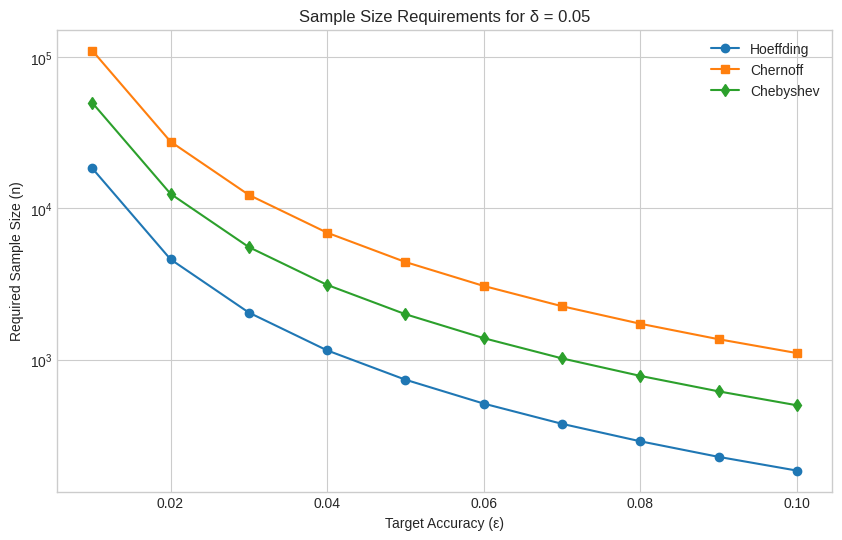


--- 2. Plotting Interval Widths and Creating Tables ---

Analyzing for p_true = 0.0:


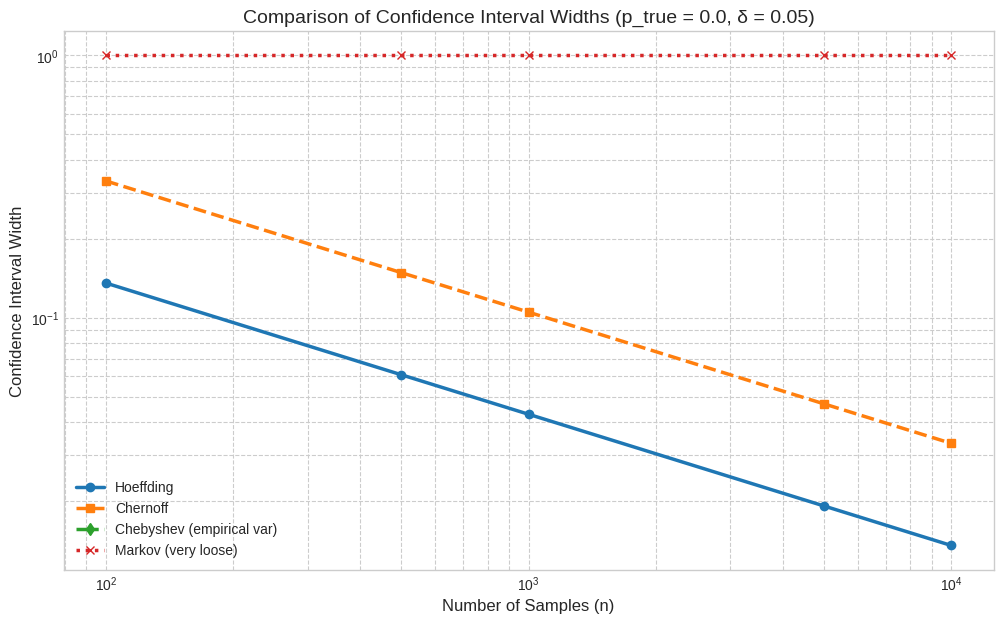

      Hoeffding Width Chernoff Width Chebyshev Width Markov Width
n                                                                
100            0.1358         0.3327          0.0000         1.00
500            0.0607         0.1488          0.0000         1.00
1000           0.0429         0.1052          0.0000         1.00
5000           0.0192         0.0470          0.0000         1.00
10000          0.0136         0.0333          0.0000         1.00

Analyzing for p_true = 0.5:


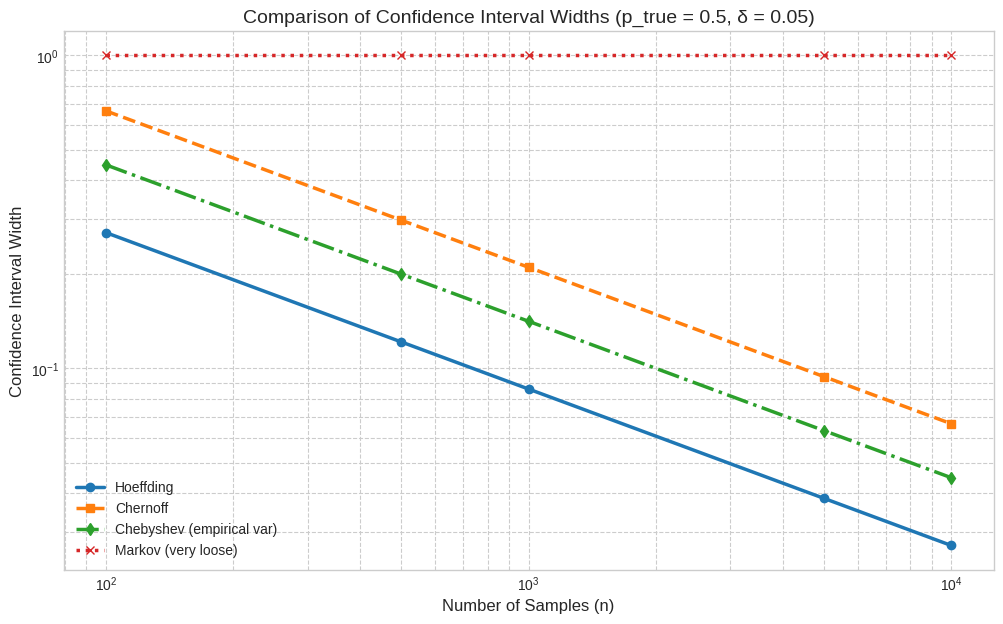

      Hoeffding Width Chernoff Width Chebyshev Width Markov Width
n                                                                
100            0.2716         0.6653          0.4472         1.00
500            0.1215         0.2975          0.2000         1.00
1000           0.0859         0.2104          0.1414         1.00
5000           0.0384         0.0941          0.0632         1.00
10000          0.0272         0.0665          0.0447         1.00

Analyzing for p_true = 1.0:


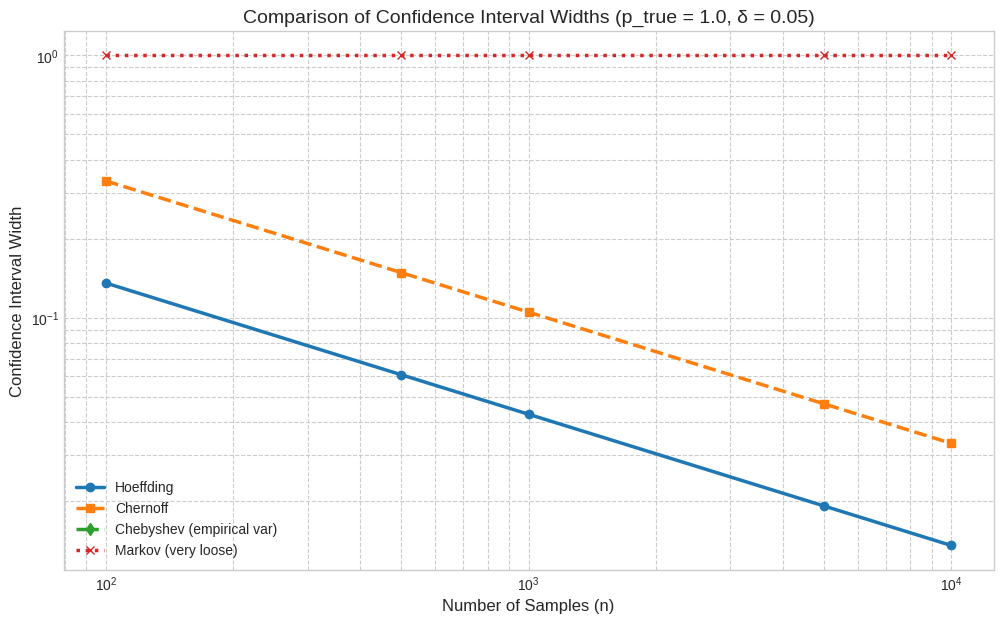

      Hoeffding Width Chernoff Width Chebyshev Width Markov Width
n                                                                
100            0.1358         0.3327          0.0000         1.00
500            0.0607         0.1488          0.0000         1.00
1000           0.0429         0.1052          0.0000         1.00
5000           0.0192         0.0470          0.0000         1.00
10000          0.0136         0.0333          0.0000         1.00


In [ ]:
# ==============================================================================
# === 1. DEFINE EXPERIMENTAL PARAMETERS ===
# ==============================================================================
p_true_values = [0.0, 0.5, 1.0]  # Test orthogonal, maximally overlapping, and identical states
delta = 0.05                      # 95% confidence level
epsilon_values = np.linspace(0.01, 0.1, 10) # A range of target accuracies
n_values = [100, 500, 1000, 5000, 10000]    # A range of sample sizes to test
n_trials = 500                     # Number of trials for empirical validation

print("Experiment Parameters:")
print(f"  - True Probabilities (p_true): {p_true_values}")
print(f"  - Confidence Level (1-delta): {1-delta}")
print(f"  - Number of trials for validation: {n_trials}\n")


# ==============================================================================
# === 2. VISUALIZE SAMPLE SIZE REQUIREMENTS ===
# ==============================================================================
print("--- 1. Plotting Sample Size Requirements ---")
plot_sample_sizes(epsilon_values, delta=delta)


# ==============================================================================
# === 3. VISUALIZE INTERVAL WIDTHS AND CREATE TABLES ===
# ==============================================================================
print("\n--- 2. Plotting Interval Widths and Creating Tables ---")

for p_true in p_true_values:
    print(f"\nAnalyzing for p_true = {p_true}:")

    # Plot the widths
    plot_interval_widths(p_true, n_values, delta=delta)

    # Create and display the table
    width_table = create_interval_width_table(p_true, n_values, delta=delta)
    print(width_table)




In [ ]:
# ==============================================================================
# === 4. (OPTIONAL) RUN THE FULL EMPIRICAL VALIDATION ===
# ==============================================================================
# This step is more computationally intensive. It verifies that the empirical
# failure rate is close to the theoretical delta.
# Uncomment the code below to run it.

print("\n--- 3. Running Full Empirical Validation (this may take a moment) ---")
# Use a smaller set of parameters for a quicker validation run
validation_results = compare_inequalities(
    p_true_values=[0.5],
    delta_values=[0.05],
    epsilon_values=[0.05],
    n_trials=200
)

# Extract and print the results
res = validation_results[0.5][0.05][0.05]
print("\nEmpirical Results for p_true=0.5, delta=0.05, epsilon=0.05:")
print(f"Method       | Planned n | Avg Width | Empirical Coverage (Target: >=0.95)")
print("-------------|-----------|-----------|------------------------------------")
for method, data in res.items():
    print(f"{method:<12} | {data['n']:<9} | {data['avg_width']:<9.4f} | {data['coverage']:.4f}")

print("\n--- Analysis Complete ---")


--- 3. Running Full Empirical Validation (this may take a moment) ---

Empirical Results for p_true=0.5, delta=0.05, epsilon=0.05:
Method       | Planned n | Avg Width | Empirical Coverage (Target: >=0.95)
-------------|-----------|-----------|------------------------------------
hoeffding    | 738       | 0.1000    | 1.0000
chernoff     | 4427      | 0.1000    | 1.0000
chebyshev    | 2000      | 0.1000    | 1.0000

--- Analysis Complete ---
